In [1]:
import glob
import ast
import time
import numpy as np
import pandas as pd
from tqdm import tqdm 
import cv2
from PIL import Image
import re
import joblib
import matplotlib.pyplot as plt
import gc
import zipfile

from tqdm import tqdm
import shutil

In [2]:
import warnings
warnings.filterwarnings('ignore')

### Loading package

In [3]:
import sys
from pathlib import Path

here_path = Path().resolve()
repo_path = here_path.parents[2]
sys.path.append(str(repo_path))

In [4]:
from py.utils import verifyDir,verifyFile

In [5]:
from py.config import Config

cfg = Config()

np.random.seed(cfg.RANDOM_STATE)
cfg.DATA_PATH, cfg.MODEL_PATH

('/media/felipe/DATA19/datasets/', '/media/felipe/DATA19/models/')

In [6]:
QSCORE_PATH=f"{cfg.DATA_PATH}pp2/Qscores/"
IMAGES_PATH = f"{cfg.DATA_PATH}pp2/images/"

ADE20K_DIR = f"{cfg.DATA_PATH}{cfg.SEG_DATASET}/"
SEGMENT_DIR = f"{cfg.DATA_PATH}pp2/segmentations/{cfg.SEG_DATASET}/{cfg.SEG_MODEL_NAME}/"

UPD4K_DIR = f"{cfg.DATA_PATH}/upd4k/"
UPD_SEGMENT_DIR = f"{cfg.DATA_PATH}UrbanPhysicalDisorder/upd4k/"

In [7]:
verifyDir(UPD_SEGMENT_DIR)

### Loading data

In [8]:
from py.datasets import UrbanPhysicalDisorder

uss = UrbanPhysicalDisorder(data_path=cfg.DATA_PATH)
uss.generate_dataset(dataset=f"{cfg.SEG_DATASET}_upd4k")

objects_df = uss.get_urban_street_categories()
objects_df

,class_id,main_class,class_name,RGB_color,hex_color,isthing,group_name
0,1,wall,wall,"(120, 120, 120)",#787878,0,construction
1,2,building,building;edifice,"(180, 120, 120)",#B47878,0,construction
2,3,sky,sky,"(6, 230, 230)",#06E6E6,0,sky
3,4,floor,floor;flooring,"(80, 50, 50)",#503232,0,floor
4,5,tree,tree,"(4, 200, 3)",#04C803,0,vegetation
...,...,...,...,...,...,...,...
158,159,graffiti,graffiti,"(170, 240, 209)",#aaf0d1,0,graffiti
159,160,homeless,homeless,"(255, 204, 51)",#ffcc33,1,homeless
160,161,kiosk,kiosk,"(204, 51, 102)",#cc3366,1,kiosk
161,162,overhead_cable,overhead_cable,"(250, 125, 187)",#fa7dbb,0,overhead_cable


### Merging masks

In [9]:
import fnmatch

In [10]:
columns_to_keep = ["image_id", "seg_image_path", "seg_overlay_image_path", "mask_path", "ratio_path"]

In [11]:
%%time
segment_df = pd.DataFrame()

for idx, current_city in enumerate(["Rio De Janeiro"]):
    print(f"{idx+1}: Evaluating {current_city}...")
    
    OUT_DIR = f"{UPD_SEGMENT_DIR}{current_city}/"
    
    verifyDir(OUT_DIR)
    verifyDir(f"{OUT_DIR}/masks/")
    verifyDir(f"{OUT_DIR}/segmented_images/")
    verifyDir(f"{OUT_DIR}/segmented_images_overlay/")
    verifyDir(f"{OUT_DIR}/ratios/")

    city_segment_df = pd.DataFrame()
    
    with zipfile.ZipFile(f'{UPD4K_DIR}/{current_city}.zip', 'r') as zip_ref:
        # Get all PNG files in SegmentationClass directory
        manual_img_seg_list = np.sort([f'{UPD4K_DIR}{f}' for f in zip_ref.namelist() 
                     if fnmatch.fnmatch(f, f'{current_city}/SegmentationClass/*.png')])
    
    manual_img_seg_ids = [ img.split("/")[-1].replace(".png", "") for img in manual_img_seg_list]
    
    img_seg_list = np.sort([f for f in glob.glob(f'{SEGMENT_DIR}/{current_city}/segmented_images/*.png') ])
    img_seg_ids = [ img.split("/")[-1].replace(".png", "") for img in img_seg_list]
    
    for img_path in tqdm(img_seg_list):
        
        current_id = img_path.split("/")[-1].replace(".JPEG", "").replace(".png", "")
        current_image = Image.open(glob.glob(f'{IMAGES_PATH}/{current_city}/{current_id}.JPG')[0]).convert("RGB")

        if verifyFile(f"{OUT_DIR}/masks/{current_id}.pkl") and verifyFile(f"{OUT_DIR}/ratios/{current_id}.csv") and verifyFile(f"{OUT_DIR}/segmented_images/{current_id}.png") and verifyFile(f"{OUT_DIR}/segmented_images_overlay/{current_id}.png"):
            ratio_df = pd.read_csv(f"{OUT_DIR}/ratios/{current_id}.csv", sep=";", low_memory=False)
            
        else:
            if current_id in manual_img_seg_ids:
                manual_img_seg = Image.open(
                                    zipfile.ZipFile(f'{UPD4K_DIR}/{current_city}.zip')
                                    .open(f'{current_city}/SegmentationClass/{current_id}.png')
                                ).convert("RGB")
                
                colors_tuple = uss.calculate_unique_colors(manual_img_seg, to_tuple=True)
        
                # Calculate manual masks ratios
                manual_masks = uss.convert_mask_to_matrix(manual_img_seg, colors_tuple, objects_df)
                
                # Calculate real masks ratios
                model_masks = joblib.load(glob.glob(f'{SEGMENT_DIR}/{current_city}/masks/{current_id}.pkl')[0])
                
                # merging masks
                merged_masks = np.where(manual_masks != 0, manual_masks, model_masks)
                joblib.dump(merged_masks, f"{OUT_DIR}/masks/{current_id}.pkl")
                ratio_df = uss.calculate_pixel_ratios(merged_masks, objects_df)
                ratio_df.to_csv(f"{OUT_DIR}/ratios/{current_id}.csv", sep=";", index=False)
        
                # merging both images
                ade20k_img_seg = Image.open(glob.glob(f'{SEGMENT_DIR}/{current_city}/segmented_images/{current_id}.png')[0]).convert("RGB")
                merged_img_seg = uss.merge_segmentations(ade20k_img_seg, manual_img_seg)
                merged_image = Image.fromarray(merged_img_seg)
                merged_image.save(f"{OUT_DIR}/segmented_images/{current_id}.png")
        
                # Overlay image
                image_overlay = Image.blend(current_image, merged_image, alpha=0.6)
                image_overlay.save(f"{OUT_DIR}/segmented_images_overlay/{current_id}.png")
        
            else:
                # copying masks
                model_masks = joblib.load(glob.glob(f'{SEGMENT_DIR}/{current_city}/masks/{current_id}.pkl')[0])
                source = glob.glob(f'{SEGMENT_DIR}/{current_city}/masks/{current_id}.pkl')[0]
                destination = f"{OUT_DIR}/masks/{current_id}.pkl"
                shutil.copy(source, destination)
        
                # copying ratios
                source = glob.glob(f'{SEGMENT_DIR}/{current_city}/ratios/{current_id}.csv')[0]
                destination = f"{OUT_DIR}/ratios/{current_id}.csv"
                shutil.copy(source, destination)
        
                # copying image segmentation
                source = glob.glob(f'{SEGMENT_DIR}/{current_city}/segmented_images/{current_id}.png')[0]
                destination = f"{OUT_DIR}/segmented_images/{current_id}.png"
                shutil.copy(source, destination)
        
                # copying image overlay
                source = glob.glob(f'{SEGMENT_DIR}/{current_city}/segmented_images_overlay/{current_id}.png')[0]
                destination = f"{OUT_DIR}/segmented_images_overlay/{current_id}.png"
                shutil.copy(source, destination)
        
                # read ratios to append
                ratio_df = pd.read_csv(f'{SEGMENT_DIR}/{current_city}/ratios/{current_id}.csv', sep=";", low_memory=False)
    
        # merge segmentations
        df_pivot = uss.parse_ratios(current_id, ratio_df)
        df_pivot["seg_image_path"] = f"{current_city}/segmented_images/{current_id}.png"
        df_pivot["seg_overlay_image_path"] = f"{current_city}/segmented_images_overlay/{current_id}.png"
        df_pivot["mask_path"] = f"{current_city}/masks/{current_id}.pkl"
        df_pivot["ratio_path"] = f"{current_city}/ratios/{current_id}.csv"

        city_segment_df = pd.concat([city_segment_df, df_pivot], ignore_index=True)
        city_segment_df = city_segment_df[columns_to_keep + [col for col in city_segment_df.columns if col not in columns_to_keep]].copy()
        city_segment_df.fillna(0, inplace=True)

    city_segment_df.fillna(0, inplace=True)
    city_segment_df.to_csv(f"{OUT_DIR}/segmentations.csv", sep=";", index=False)

    segment_df = pd.concat([segment_df, city_segment_df], ignore_index=True)
    segment_df.fillna(0, inplace=True)

1: Evaluating Rio De Janeiro...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3644/3644 [00:19<00:00, 185.34it/s]


CPU times: user 16.9 s, sys: 2.93 s, total: 19.9 s
Wall time: 19.9 s


In [12]:
segment_df

,image_id,seg_image_path,seg_overlay_image_path,mask_path,ratio_path,broken_damaged_pavement_road,building,car,door,fence,...,skyscraper,flower,ball,sink,swimming_pool,shelf,billiard,carpet,curtain,mirror
0,50f5ea5bfdc9f065f0007ab0,Rio De Janeiro/segmented_images/50f5ea5bfdc9f0...,Rio De Janeiro/segmented_images_overlay/50f5ea...,Rio De Janeiro/masks/50f5ea5bfdc9f065f0007ab0.pkl,Rio De Janeiro/ratios/50f5ea5bfdc9f065f0007ab0...,5.405000,5.768333,1.295000,0.860833,4.035833,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,50f5ea5bfdc9f065f0007ab1,Rio De Janeiro/segmented_images/50f5ea5bfdc9f0...,Rio De Janeiro/segmented_images_overlay/50f5ea...,Rio De Janeiro/masks/50f5ea5bfdc9f065f0007ab1.pkl,Rio De Janeiro/ratios/50f5ea5bfdc9f065f0007ab1...,0.000000,6.805000,7.540000,0.000000,0.901667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,50f5ea5bfdc9f065f0007ab2,Rio De Janeiro/segmented_images/50f5ea5bfdc9f0...,Rio De Janeiro/segmented_images_overlay/50f5ea...,Rio De Janeiro/masks/50f5ea5bfdc9f065f0007ab2.pkl,Rio De Janeiro/ratios/50f5ea5bfdc9f065f0007ab2...,0.000000,19.880833,0.271667,3.886667,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,50f5ea5bfdc9f065f0007ab3,Rio De Janeiro/segmented_images/50f5ea5bfdc9f0...,Rio De Janeiro/segmented_images_overlay/50f5ea...,Rio De Janeiro/masks/50f5ea5bfdc9f065f0007ab3.pkl,Rio De Janeiro/ratios/50f5ea5bfdc9f065f0007ab3...,0.000000,1.163333,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,50f5ea5bfdc9f065f0007ab4,Rio De Janeiro/segmented_images/50f5ea5bfdc9f0...,Rio De Janeiro/segmented_images_overlay/50f5ea...,Rio De Janeiro/masks/50f5ea5bfdc9f065f0007ab4.pkl,Rio De Janeiro/ratios/50f5ea5bfdc9f065f0007ab4...,0.000000,39.943333,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3639,50f5ec44fdc9f065f000890f,Rio De Janeiro/segmented_images/50f5ec44fdc9f0...,Rio De Janeiro/segmented_images_overlay/50f5ec...,Rio De Janeiro/masks/50f5ec44fdc9f065f000890f.pkl,Rio De Janeiro/ratios/50f5ec44fdc9f065f000890f...,5.516667,18.544167,0.000000,0.000000,0.350833,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3640,50f5ec44fdc9f065f0008910,Rio De Janeiro/segmented_images/50f5ec44fdc9f0...,Rio De Janeiro/segmented_images_overlay/50f5ec...,Rio De Janeiro/masks/50f5ec44fdc9f065f0008910.pkl,Rio De Janeiro/ratios/50f5ec44fdc9f065f0008910...,3.986667,35.478333,8.090000,0.000000,0.007500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3641,50f5ec44fdc9f065f0008911,Rio De Janeiro/segmented_images/50f5ec44fdc9f0...,Rio De Janeiro/segmented_images_overlay/50f5ec...,Rio De Janeiro/masks/50f5ec44fdc9f065f0008911.pkl,Rio De Janeiro/ratios/50f5ec44fdc9f065f0008911...,9.031667,25.838333,0.038333,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3642,50f5ec44fdc9f065f0008912,Rio De Janeiro/segmented_images/50f5ec44fdc9f0...,Rio De Janeiro/segmented_images_overlay/50f5ec...,Rio De Janeiro/masks/50f5ec44fdc9f065f0008912.pkl,Rio De Janeiro/ratios/50f5ec44fdc9f065f0008912...,7.010833,5.585833,0.670833,0.000000,7.335000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
np.sort(segment_df.columns)

array(['airplane', 'animal', 'armchair', 'ashcan', 'awning', 'bag',
       'ball', 'basket', 'bench', 'bicycle', 'billiard', 'boat', 'bottle',
       'box', 'bridge', 'broken_damaged_bricks_wall',
       'broken_damaged_pavement_road', 'broken_window', 'building',
       'bulletin', 'bus', 'car', 'car_police', 'car_taxi', 'carpet',
       'ceiling', 'chair', 'clock', 'column', 'conveyor', 'curtain',
       'damaged_traffic_sign', 'door', 'fan', 'fence', 'field', 'flag',
       'floor', 'flower', 'flowerpot', 'fountain', 'garbage_bag',
       'garbage_box', 'graffiti', 'grandstand', 'grass', 'ground',
       'handrail', 'hill', 'homeless', 'house', 'image_id', 'kiosk',
       'lake', 'lamp', 'land', 'light', 'mask_path', 'mirror',
       'motorcycle', 'mountain', 'overhead_cable', 'palm', 'path',
       'pedestal', 'person', 'pier', 'plant', 'plaything', 'pole',
       'poster', 'railing', 'ratio_path', 'river', 'road', 'rock', 'sand',
       'sculpture', 'sea', 'seg_image_path', 'seg_o

In [14]:
segment_df.to_csv(f"{UPD_SEGMENT_DIR}/segmentations.csv", sep=";", index=False)

### Summary

In [15]:
manual_segment_df = segment_df[columns_to_keep + uss.upd4k_labels].copy()

In [16]:
manual_segment_df.shape, segment_df.shape#, model_segment_df.shape

((3644, 18), (3644, 113))

In [17]:
set(segment_df.columns) - set(manual_segment_df.columns)#, set(segment_df.columns) - set(model_segment_df.columns)

{'airplane',
 'animal',
 'armchair',
 'ashcan',
 'awning',
 'bag',
 'ball',
 'basket',
 'bench',
 'bicycle',
 'billiard',
 'boat',
 'bottle',
 'box',
 'bridge',
 'building',
 'bulletin',
 'bus',
 'car',
 'carpet',
 'ceiling',
 'chair',
 'clock',
 'column',
 'conveyor',
 'curtain',
 'door',
 'fan',
 'fence',
 'field',
 'flag',
 'floor',
 'flower',
 'flowerpot',
 'fountain',
 'grandstand',
 'grass',
 'ground',
 'handrail',
 'hill',
 'house',
 'lake',
 'lamp',
 'land',
 'light',
 'mirror',
 'motorcycle',
 'mountain',
 'palm',
 'path',
 'pedestal',
 'person',
 'pier',
 'plant',
 'plaything',
 'pole',
 'poster',
 'railing',
 'river',
 'road',
 'rock',
 'sand',
 'sculpture',
 'sea',
 'shack',
 'shelf',
 'ship',
 'sidewalk',
 'signboard',
 'sink',
 'sky',
 'skyscraper',
 'sofa',
 'sofa_pillow',
 'stadium',
 'stairs',
 'stairway',
 'stand',
 'steps',
 'stoplight',
 'streetlight',
 'swimming_pool',
 'table',
 'tank',
 'television',
 'tent',
 'tower',
 'trade',
 'tree',
 'truck',
 'van',
 'vitri

In [18]:
metric="safety"

In [19]:
%%time
data_df = pd.read_csv(f"{QSCORE_PATH}scores.csv", sep=";", low_memory=False)
manual_segmentation_df = pd.merge(data_df, manual_segment_df, on="image_id", how="inner")
manual_segmentation_df.sort_values(by=metric, inplace=True, ascending=False)
manual_segmentation_df

CPU times: user 136 ms, sys: 23.1 ms, total: 159 ms
Wall time: 160 ms


,image_id,lat,long,city,country,continent,safety,beautiful,wealthy,lively,...,car_police,car_taxi,damaged_traffic_sign,garbage_bag,garbage_box,graffiti,homeless,kiosk,overhead_cable,trashcan
887,50f5eaecfdc9f065f0007e32,-22.901318,-43.178843,Rio De Janeiro,Brasil,South America,8.074111,7.222222,6.521164,5.259259,...,0.0,10.947500,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0
1822,50f5eb4bfdc9f065f00081e0,-22.924839,-43.387912,Rio De Janeiro,Brasil,South America,7.990805,3.015873,3.333333,3.767806,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.183333,0.0
1964,50f5eb65fdc9f065f000826f,-22.829954,-43.374070,Rio De Janeiro,Brasil,South America,7.920455,3.740079,3.117284,3.333333,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0
1671,50f5eb44fdc9f065f0008149,-22.946271,-43.371826,Rio De Janeiro,Brasil,South America,7.845118,5.000000,3.333333,3.347885,...,0.0,0.341667,0.0,0.000000,0.0,0.000000,0.000000,0.0,2.020833,0.0
176,50f5eaa3fdc9f065f0007b62,-22.848260,-43.265251,Rio De Janeiro,Brasil,South America,7.784127,2.222222,3.333333,4.777778,...,0.0,0.000000,0.0,0.000000,0.0,3.378333,0.000000,0.0,2.600000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2758,50f5ebcefdc9f065f0008595,-22.875385,-43.278050,Rio De Janeiro,Brasil,South America,0.833333,2.190476,2.500000,1.929293,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0
1446,50f5eb26fdc9f065f0008065,-22.912840,-43.252074,Rio De Janeiro,Brasil,South America,0.833333,3.574074,2.666667,2.893366,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0
531,50f5eac8fdc9f065f0007ccc,-22.775293,-43.391274,Rio De Janeiro,Brasil,South America,0.833333,2.500000,1.666667,5.274365,...,0.0,0.000000,0.0,0.031667,0.0,0.000000,0.000000,0.0,0.257500,0.0
1471,50f5eb27fdc9f065f000807f,-22.853284,-43.319558,Rio De Janeiro,Brasil,South America,0.512821,3.333333,2.222222,4.174539,...,0.0,0.000000,0.0,0.000000,0.0,3.913333,0.000000,0.0,14.516667,0.0


### Object Presence

#### All samples

In [20]:
manual_segmentation_df.info()

<class 'pandas.DataFrame'>
Index: 3644 entries, 887 to 3638
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   image_id                      3644 non-null   str    
 1   lat                           3644 non-null   float64
 2   long                          3644 non-null   float64
 3   city                          3644 non-null   str    
 4   country                       3644 non-null   str    
 5   continent                     3644 non-null   str    
 6   safety                        3644 non-null   float64
 7   beautiful                     3644 non-null   float64
 8   wealthy                       3644 non-null   float64
 9   lively                        3644 non-null   float64
 10  boring                        3644 non-null   float64
 11  depressing                    3644 non-null   float64
 12  image_path                    3644 non-null   str    
 13  seg_image_path   

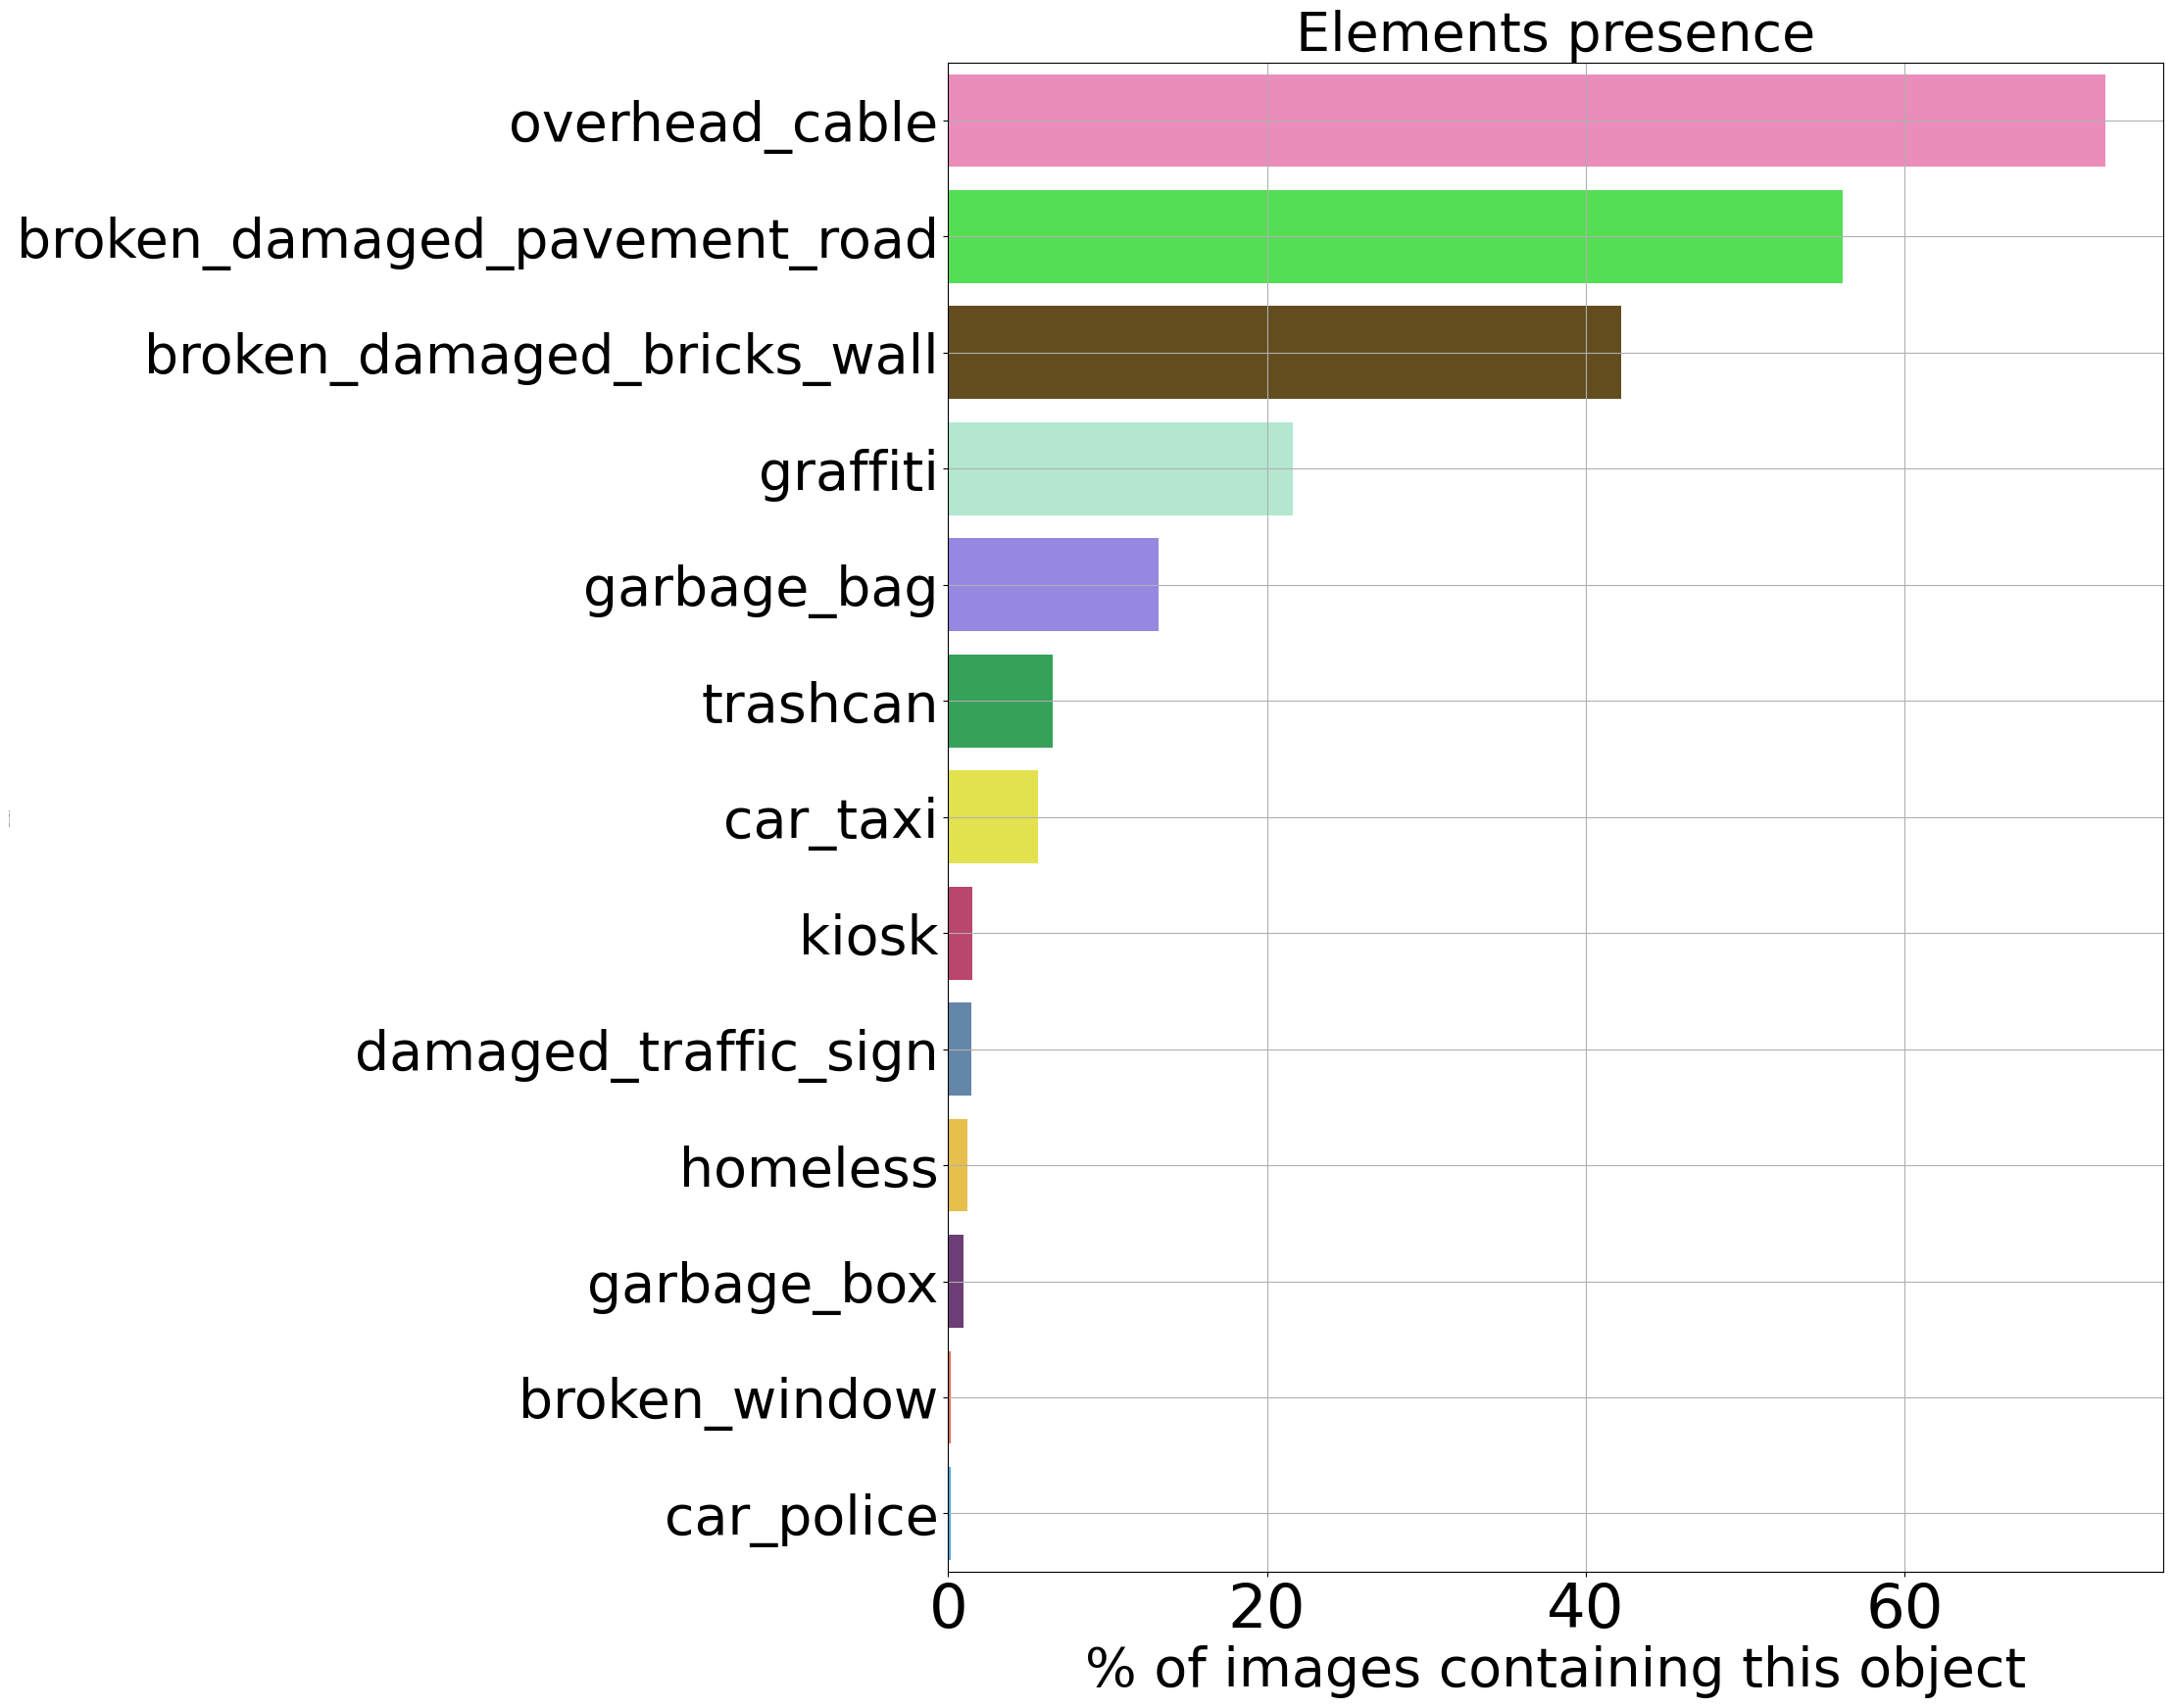

In [21]:
feature_presence = uss.features_presence(manual_segmentation_df.iloc[:, 17:])
feature_presence[0] = feature_presence[0]*100
uss.print_object_present(feature_presence, fig_size=(16,20))

#### Positive samples

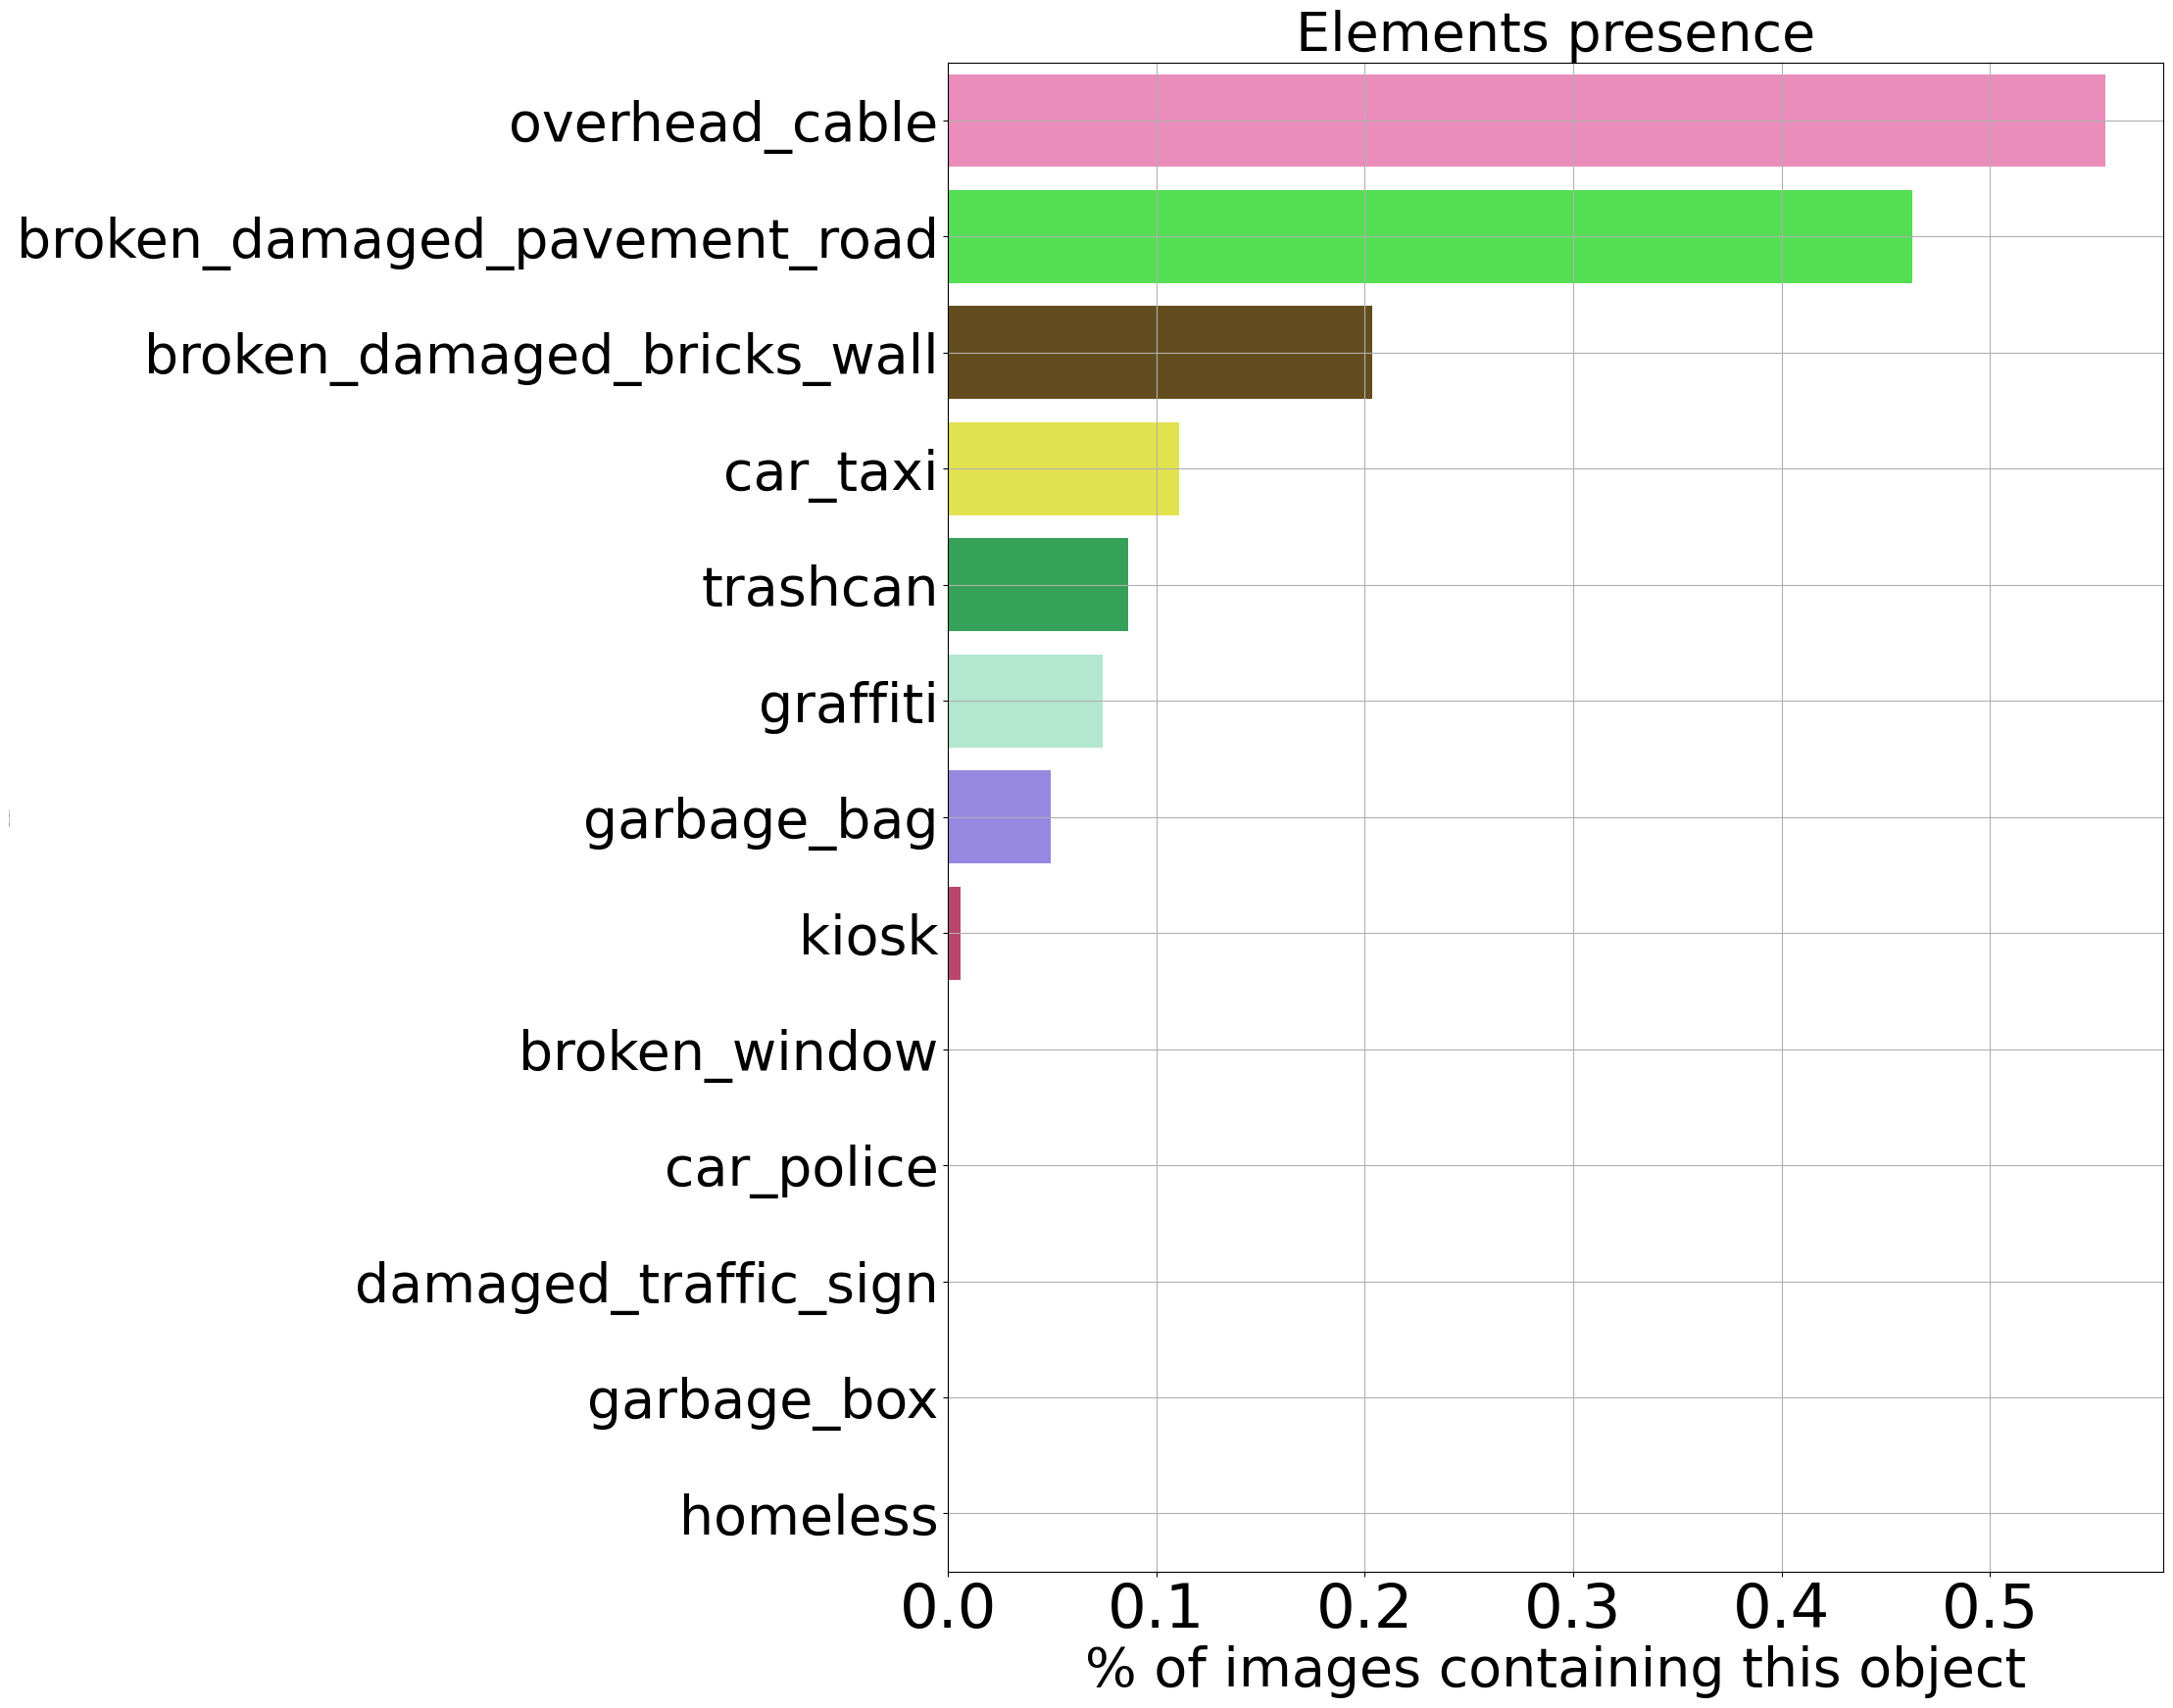

In [22]:
feature_presence = uss.features_presence(manual_segmentation_df[manual_segmentation_df[metric]>=6].iloc[:, 17:])
uss.print_object_present(feature_presence, fig_size=(16,20))

#### Negative samples

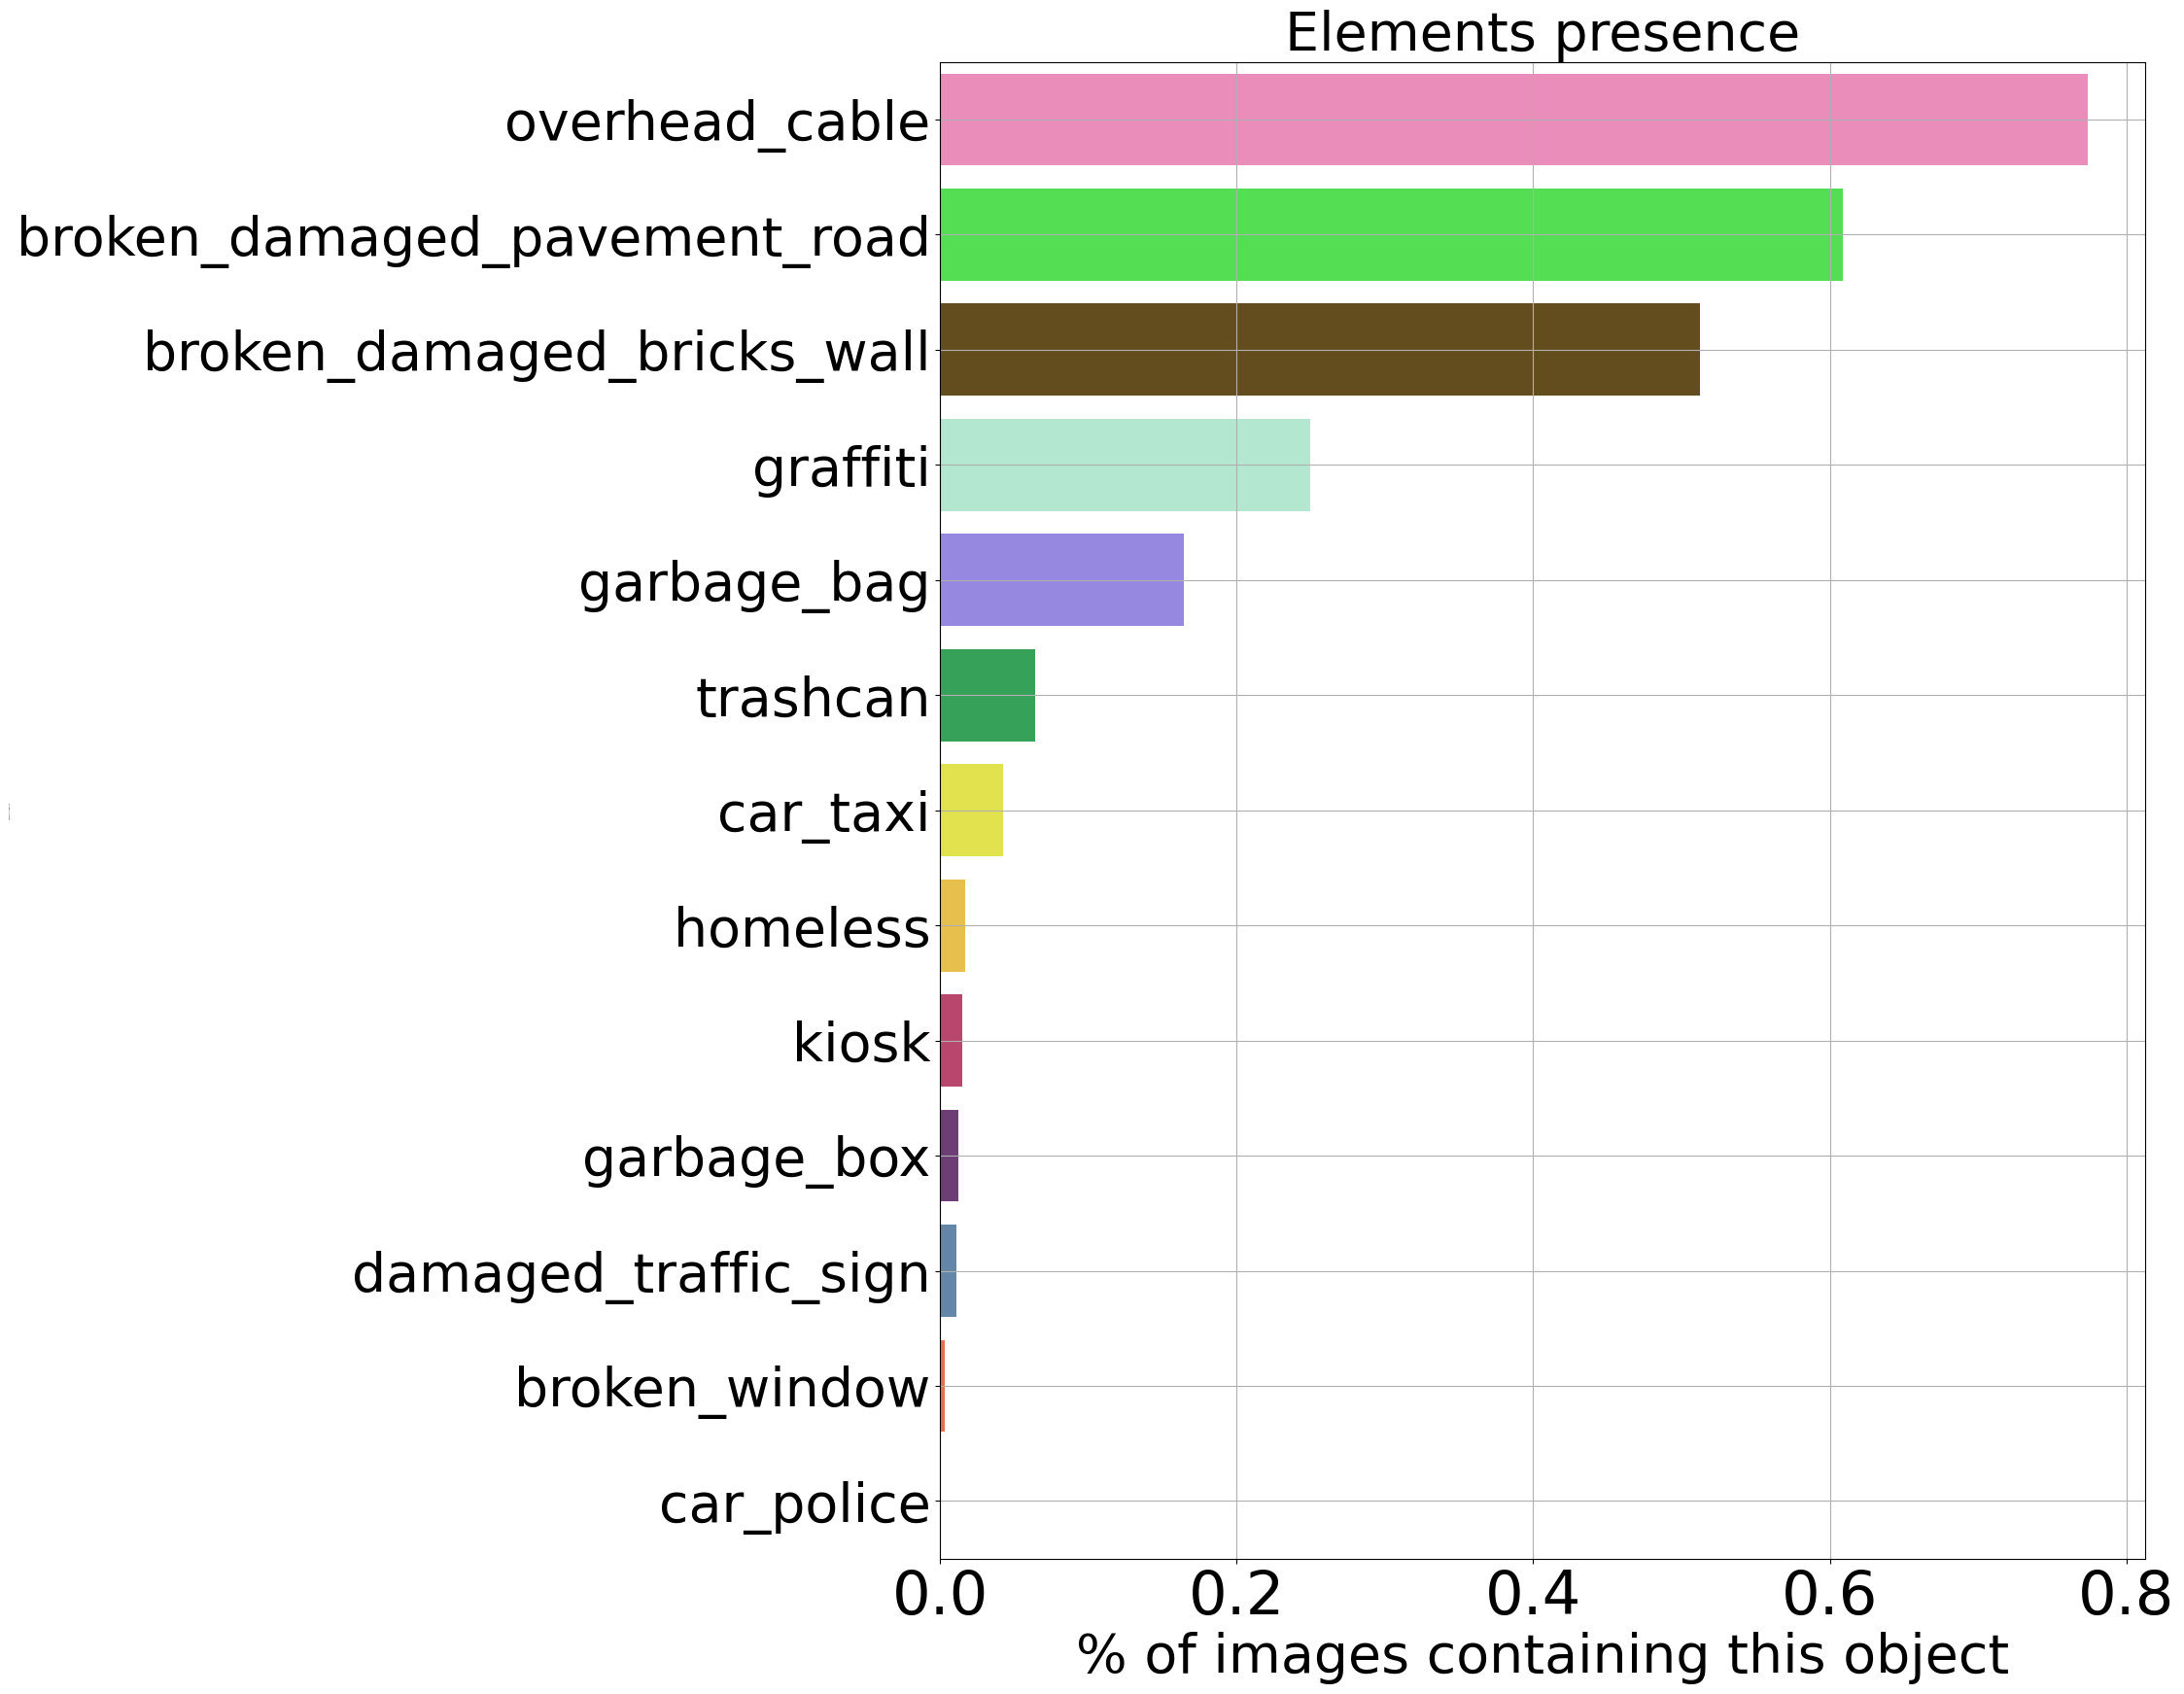

In [23]:
feature_presence = uss.features_presence(manual_segmentation_df[manual_segmentation_df[metric]<4].iloc[:, 17:])
uss.print_object_present(feature_presence, fig_size=(16,20))

### Boxplots

#### All samples

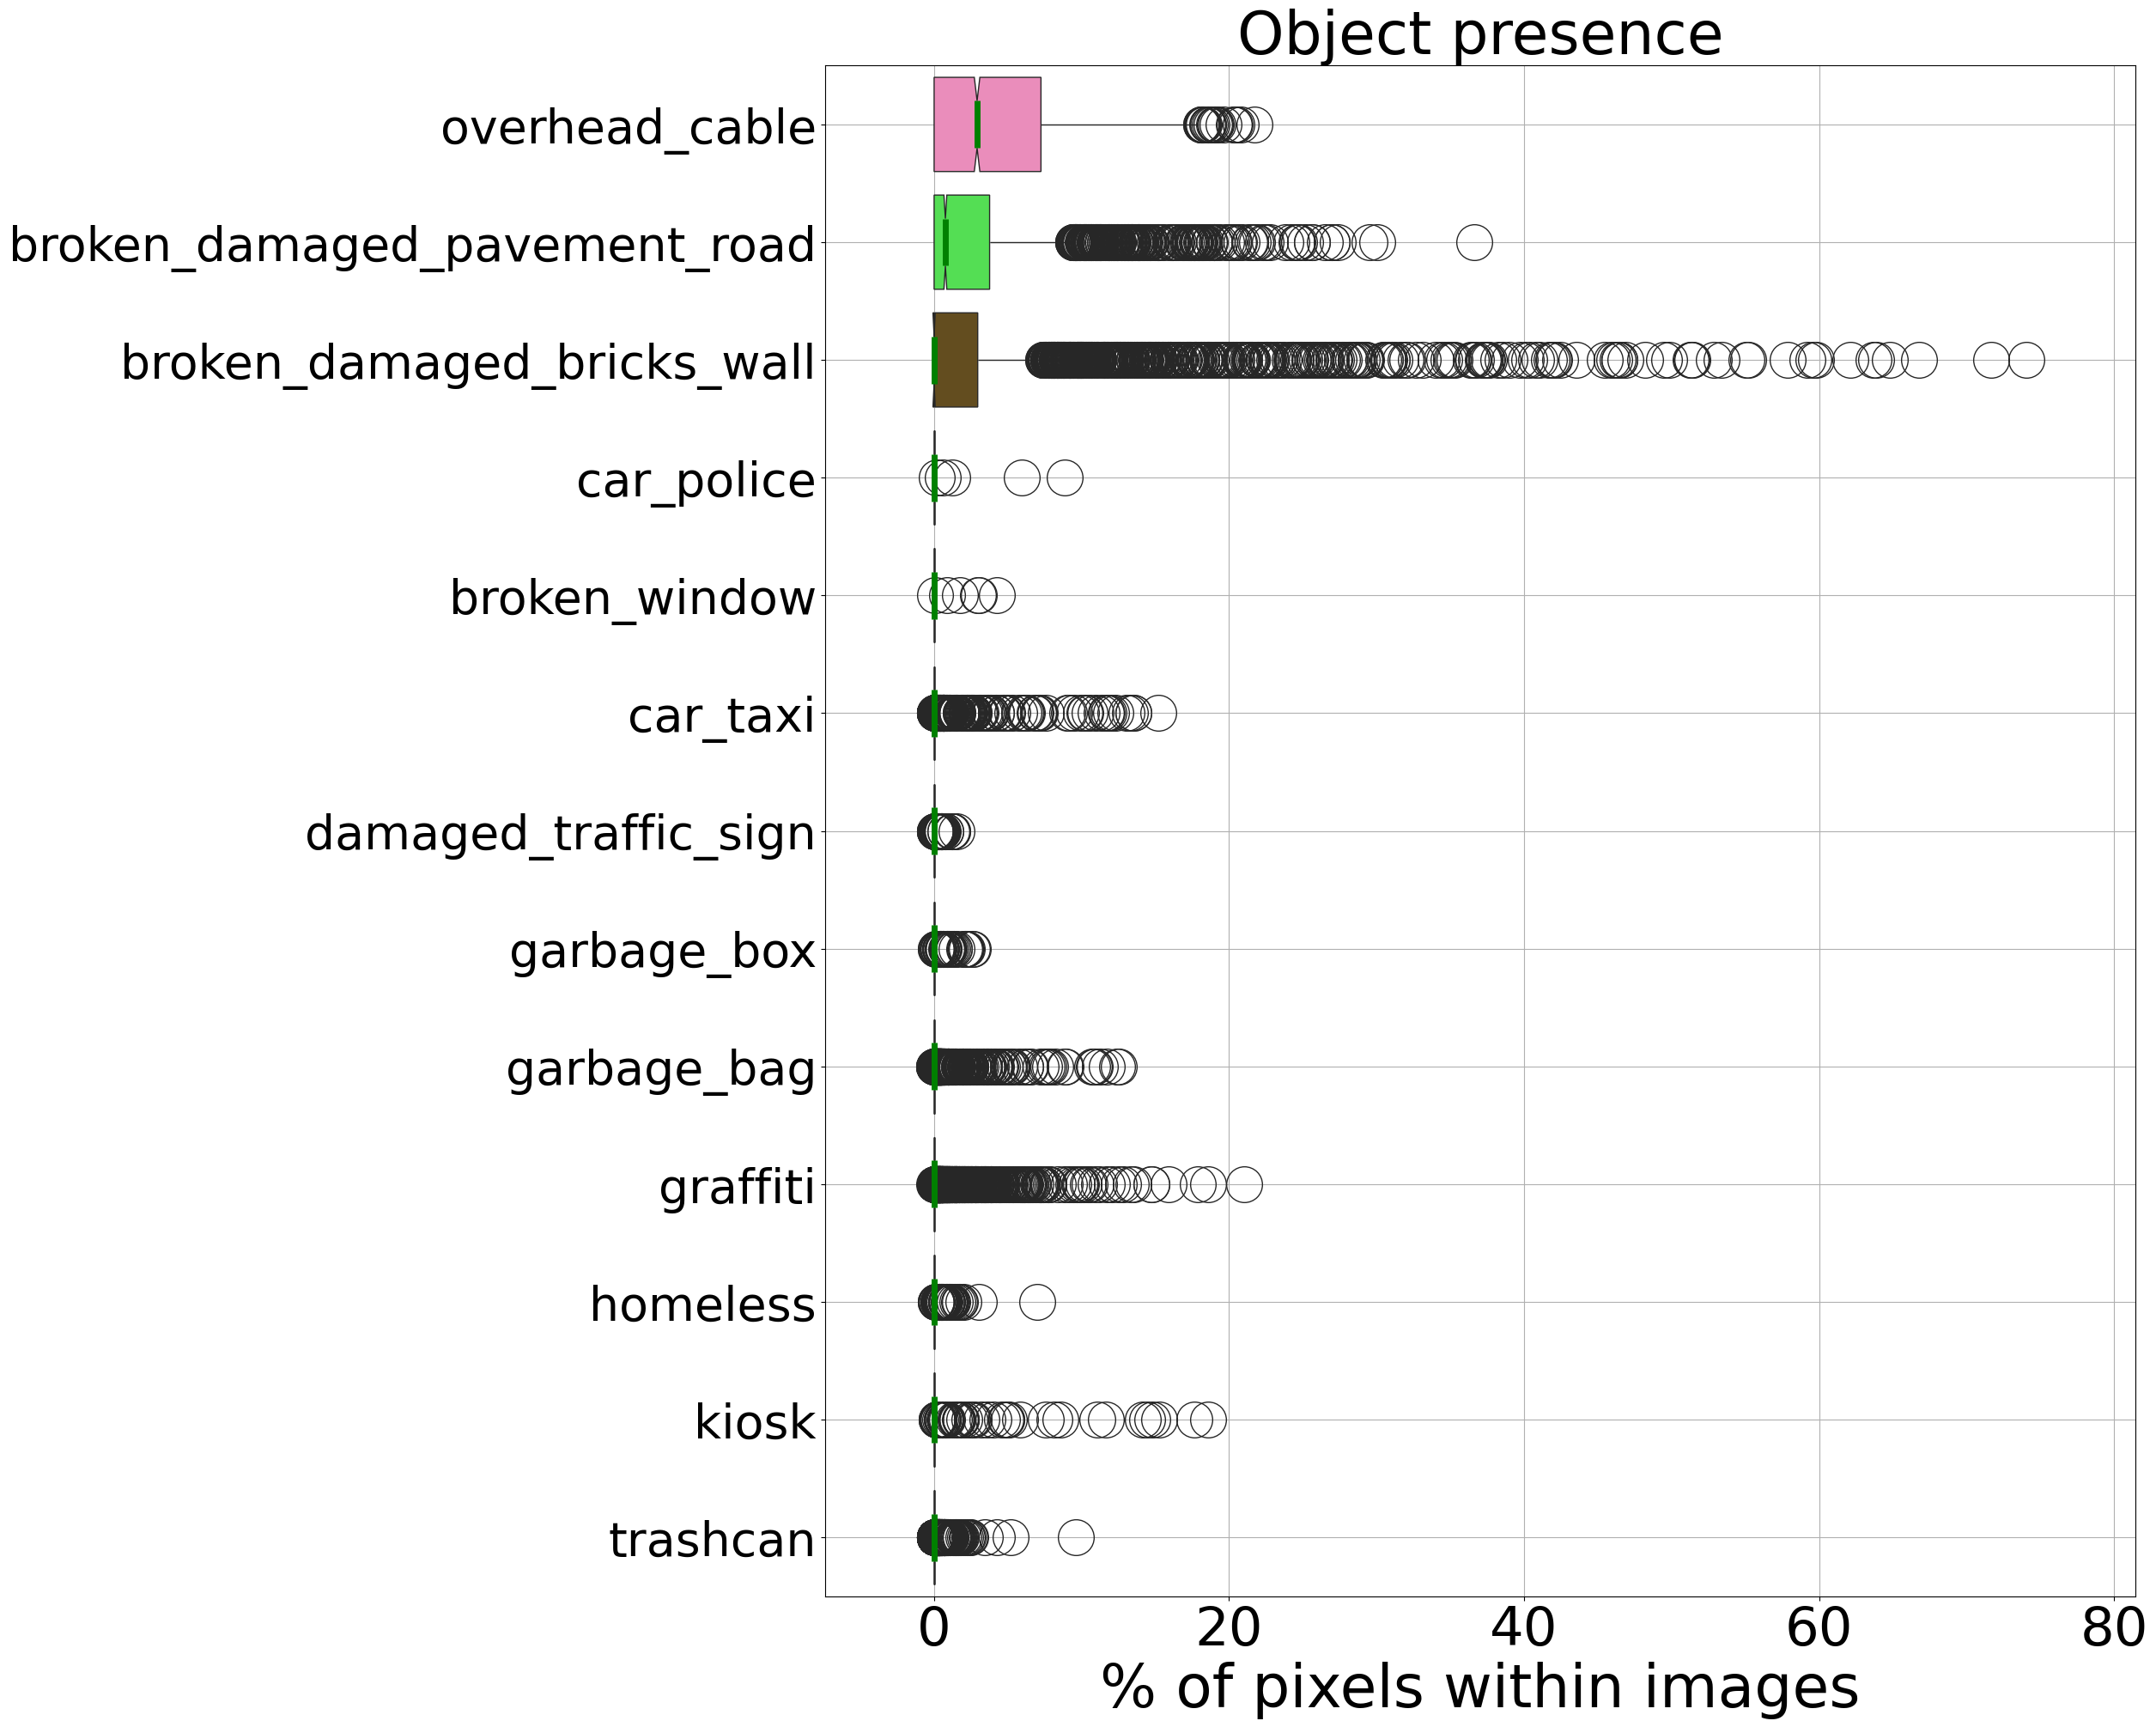

In [24]:
uss.print_object_boxplot(manual_segmentation_df.iloc[:, 17:]*100, fig_size=(25, 20))

#### Positive samples

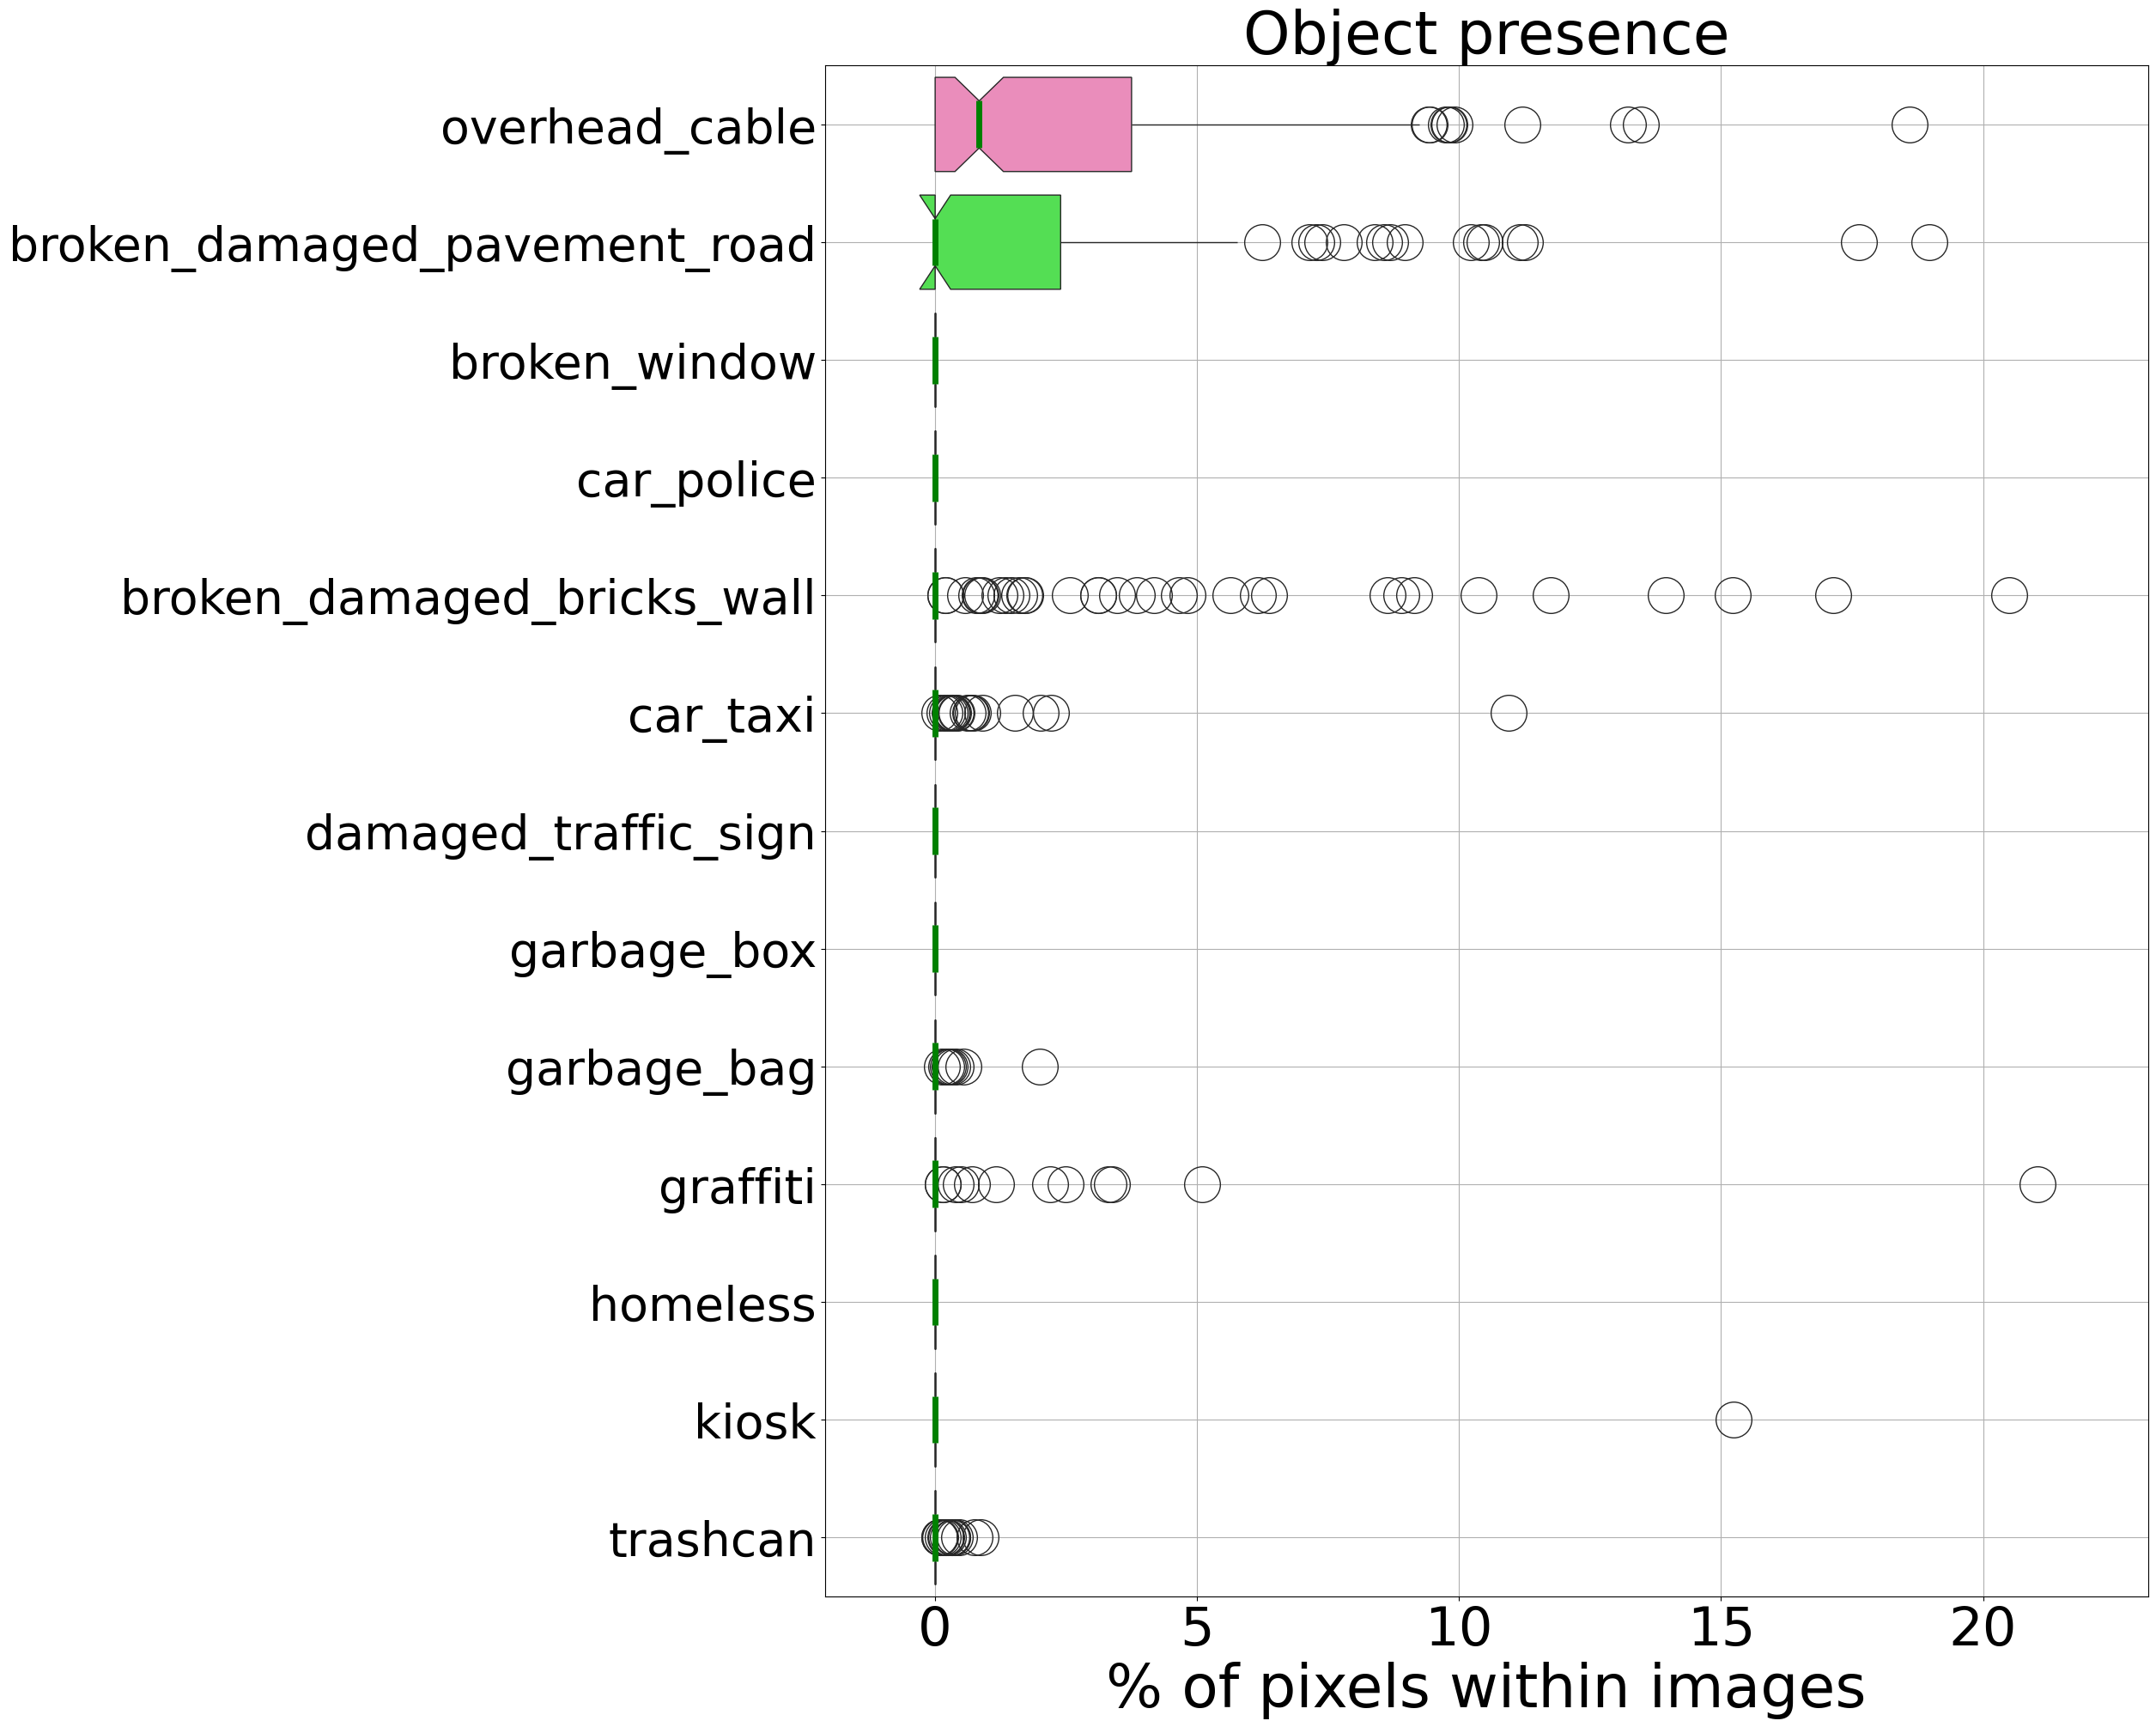

In [25]:
uss.print_object_boxplot(manual_segmentation_df[manual_segmentation_df[metric]>=6].iloc[:, 17:]*100, fig_size=(25, 20))

#### Negative samples

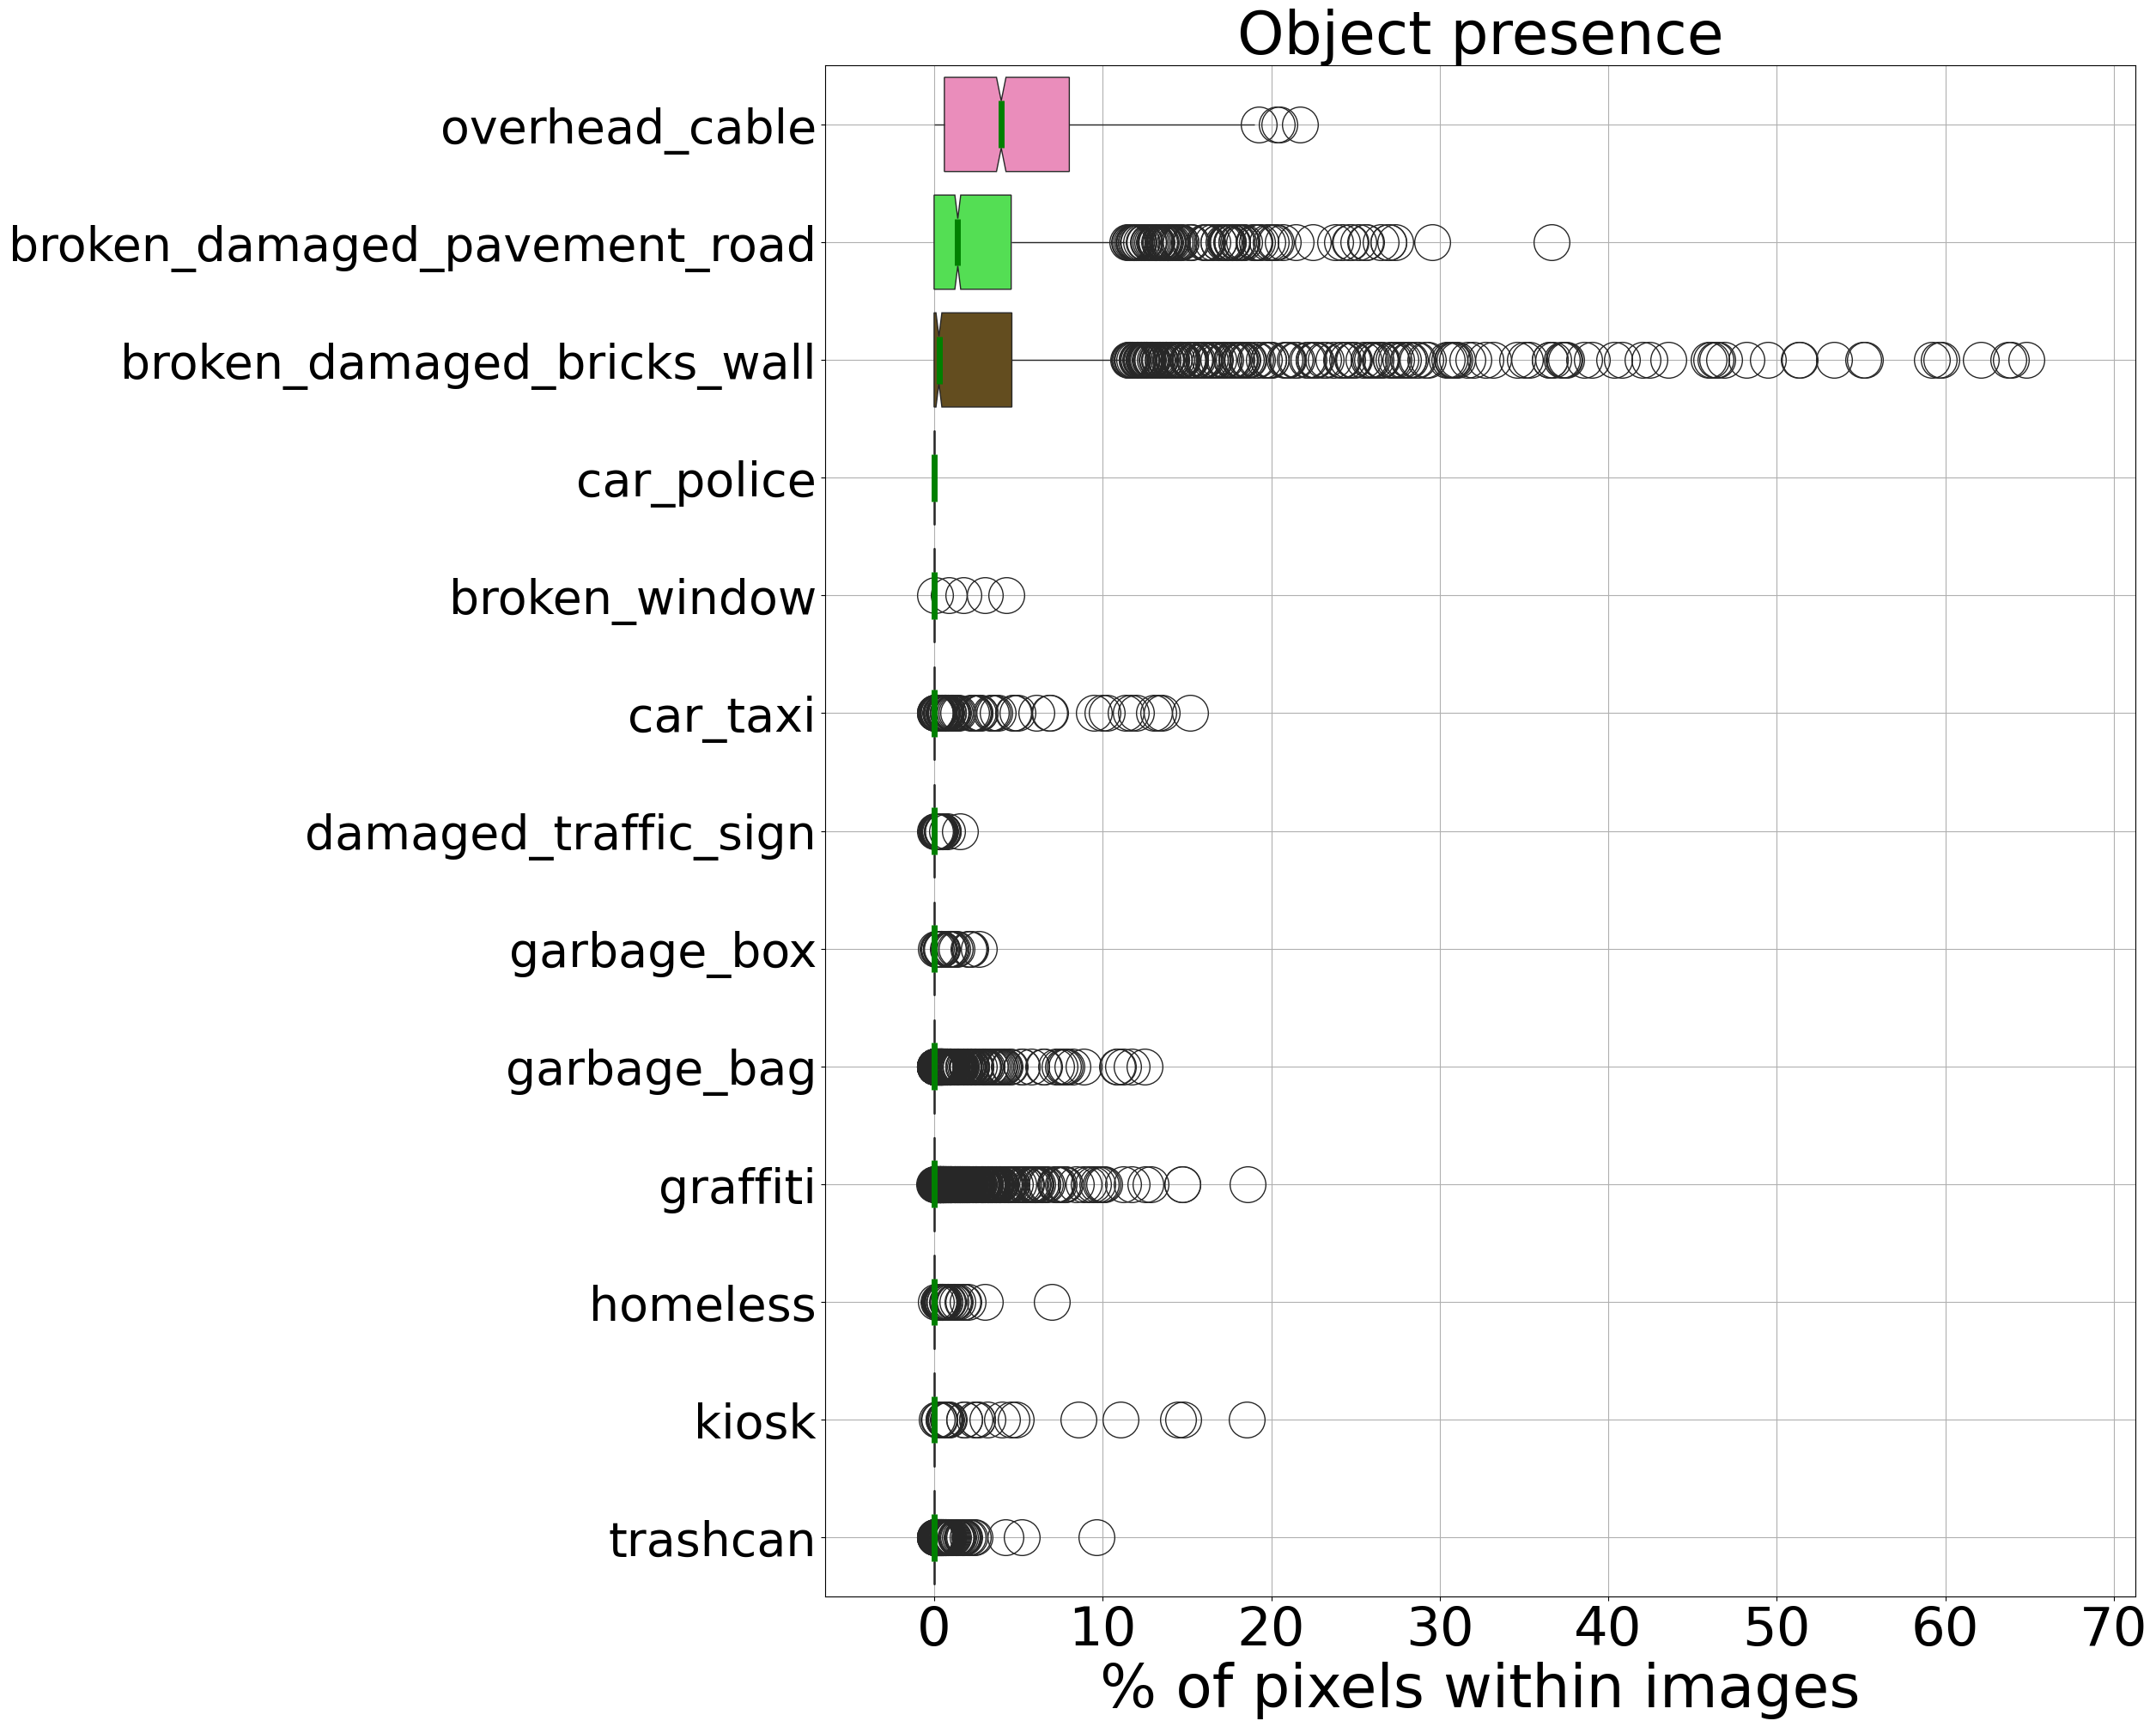

In [26]:
uss.print_object_boxplot(manual_segmentation_df[manual_segmentation_df[metric]<4].iloc[:, 17:]*100, fig_size=(25, 20))